In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

# load data
df_deaths = pd.read_csv('../data/Deaths_1x1.txt', skiprows=2, sep=r'\s+')
df_deaths['Age'] = df_deaths['Age'].replace('110+', 110).astype(int)
df_exposure = pd.read_csv('../data/Exposures_1x1.txt', skiprows=2, sep=r'\s+')
df_exposure['Age'] = df_exposure['Age'].replace('110+', 110).astype(int)

df = df_deaths.merge(df_exposure, on=['Year', 'Age'], suffixes=('_deaths', '_exp'))
df['mx_total'] = df['Total_deaths'] / df['Total_exp']
df = df[(df['Age'] <= 100) & (df['mx_total'] > 0)].copy()
df['log_mx_total'] = np.log(df['mx_total'])

# feature engineering
df['log_age'] = np.log1p(df['Age'])
df['age_squared'] = df['Age'] ** 2

# temporal split
train_mask = df['Year'] <= 2000
features = ['Age', 'Year', 'log_age', 'age_squared']

X_train = df[features][train_mask].values
X_test = df[features][~train_mask].values
y_train = df['log_mx_total'][train_mask].values
y_test = df['log_mx_total'][~train_mask].values

# scale features — important for neural nets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (8080, 4), Test: (2121, 4)


In [2]:
# define the neural network
class MortalityNet(nn.Module):
    def __init__(self):
        super(MortalityNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64),   # 4 input features
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)    # single output — log mortality
        )
    
    def forward(self, x):
        return self.network(x).squeeze()

# convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test)

# create dataloader for batching
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# initialise model, loss, optimiser
model = MortalityNet()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

MortalityNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
Total parameters: 2945


Epoch 50/1000 — Train Loss: 0.0070  Test Loss: 0.0569
Epoch 100/1000 — Train Loss: 0.0076  Test Loss: 0.0734
Epoch 150/1000 — Train Loss: 0.0066  Test Loss: 0.0516
Epoch 200/1000 — Train Loss: 0.0066  Test Loss: 0.0491
Epoch 250/1000 — Train Loss: 0.0066  Test Loss: 0.0504
Epoch 300/1000 — Train Loss: 0.0076  Test Loss: 0.0512
Epoch 350/1000 — Train Loss: 0.0066  Test Loss: 0.0563
Epoch 400/1000 — Train Loss: 0.0065  Test Loss: 0.0569
Epoch 450/1000 — Train Loss: 0.0068  Test Loss: 0.0499
Epoch 500/1000 — Train Loss: 0.0070  Test Loss: 0.0557
Epoch 550/1000 — Train Loss: 0.0082  Test Loss: 0.0530
Epoch 600/1000 — Train Loss: 0.0063  Test Loss: 0.0531
Epoch 650/1000 — Train Loss: 0.0071  Test Loss: 0.0534
Epoch 700/1000 — Train Loss: 0.0063  Test Loss: 0.0489
Epoch 750/1000 — Train Loss: 0.0066  Test Loss: 0.0626
Epoch 800/1000 — Train Loss: 0.0065  Test Loss: 0.0529
Epoch 850/1000 — Train Loss: 0.0072  Test Loss: 0.0474
Epoch 900/1000 — Train Loss: 0.0066  Test Loss: 0.0538
Epoch 950/1

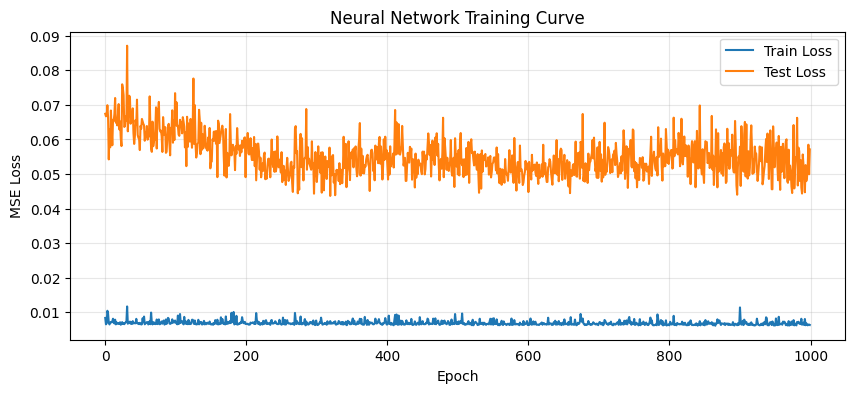

In [ ]:
epochs = 1000
train_losses = []
test_losses = []

for epoch in range(epochs):
    # training phase
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # evaluation phase
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t)
        test_pred = model(X_test_t)
        train_loss = criterion(train_pred, y_train_t).item()
        test_loss = criterion(test_pred, y_test_t).item()
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {train_loss:.4f}  Test Loss: {test_loss:.4f}")

# plot training curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Neural Network Training Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_t).numpy()
    y_pred_train = model(X_train_t).numpy()

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("Neural Network Performance:")
print(f"Train MAE: {mae_train:.4f}  |  Test MAE:  {mae_test:.4f}")
print(f"Train RMSE: {rmse_train:.4f} |  Test RMSE: {rmse_test:.4f}")
print()
print("Benchmarks (OOS):")
print(f"Lee-Carter — MAE: 0.2367  RMSE: 0.2896")
print(f"XGBoost    — MAE: 0.2665  RMSE: 0.3366")

Neural Network Performance:
Train MAE: 0.0587  |  Test MAE:  0.1998
Train RMSE: 0.0796 |  Test RMSE: 0.2390

Benchmarks (OOS):
Lee-Carter — MAE: 0.2367  RMSE: 0.2896
XGBoost    — MAE: 0.2665  RMSE: 0.3366
